In [ ]:
# Question 1: What is Simple Linear Regression?
# Answer:
# Simple Linear Regression (SLR) is a statistical method used to model the relationship between two variables — one independent variable (X) and one dependent variable (Y).
# The relationship is modeled by fitting a straight line of the form:
# Y=β_0+β_1 X+ϵ

# where:
# 	β_0= intercept,
# 	β_1= slope (rate of change of Y with respect to X),
# 	ϵ= random error term.
# SLR helps predict the value of the dependent variable based on the known value of the independent variable.


In [ ]:
# Question 2: What are the key assumptions of Simple Linear Regression?

# Answer:

# Linearity – The relationship between X and Y is linear.

# Independence – Observations are independent of each other.

# Homoscedasticity – Constant variance of residuals (no heteroscedasticity).

# Normality – The residuals are normally distributed.

# No autocorrelation – Residuals are not correlated with each other.

# Violating these assumptions can lead to biased or inefficient estimates.

In [ ]:
# Question 3: What is heteroscedasticity, and why is it important to address in regression models?

# Answer:
# Heteroscedasticity occurs when the variance of the residuals (errors) is not constant across all levels of the independent variable(s).

# It is important to address because:

# It violates regression assumptions.

# It can lead to inefficient estimates of coefficients.

# Standard errors become unreliable, leading to incorrect significance tests.

# Common fixes include log transformations, weighted least squares, or robust standard errors.

In [ ]:
# Question 4: What is Multiple Linear Regression?
# Answer:
# Multiple Linear Regression (MLR) extends simple linear regression by using two or more independent variables to predict the dependent variable.
# Y=β_0+β_1 X_1+β_2 X_2+⋯+β_n X_n+ϵ

# MLR helps model more complex relationships and understand how multiple factors together influence the outcome.


In [ ]:
Question 5: What is polynomial regression, and how does it differ from linear regression?
Answer:
Polynomial regression models the relationship between the independent variable and dependent variable as an nth-degree polynomial.
Example for 2nd degree:
Y=β_0+β_1 X+β_2 X^2+ϵ

Difference:
	Linear regression fits a straight line.
	Polynomial regression fits a curve, allowing for non-linear relationships while still being linear in coefficients.

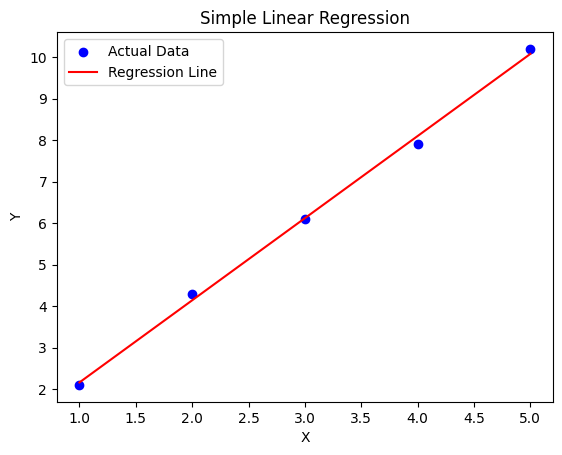

Intercept: 0.17999999999999794
Slope: 1.9800000000000004


In [ ]:
# Question 6: Python – Simple Linear Regression

# Data:
# X = [1, 2, 3, 4, 5]
# Y = [2.1, 4.3, 6.1, 7.9, 10.2]

# Answer (Python Code):

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

# Model
model = LinearRegression()
model.fit(X, Y)

# Predictions
Y_pred = model.predict(X)

# Plot
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred, color='red', label='Regression Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

# Coefficients
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

In [ ]:
# Question 7: Multiple Linear Regression + VIF Check

# Dataset:

# Area	Rooms	Price
# 1200	2	250000
# 1500	3	300000
# 1800	3	320000
# 2000	4	370000

In [1]:
# ANSWER 7)
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Data
data = pd.DataFrame({
    'Area': [1200, 1500, 1800, 2000],
    'Rooms': [2, 3, 3, 4],
    'Price': [250000, 300000, 320000, 370000]
})

X = data[['Area', 'Rooms']]
Y = data['Price']

# Add constant
X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)
Interpretation:

# If VIF > 5 or 10, multicollinearity exists.

# Likely here, Area and Rooms may have moderate correlation.

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     351.0
Date:                Fri, 17 Oct 2025   Prob (F-statistic):             0.0377
Time:                        15:03:25   Log-Likelihood:                -35.242
No. Observations:                   4   AIC:                             76.48
Df Residuals:                       1   BIC:                             74.64
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.032e+05   9488.293     10.872      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


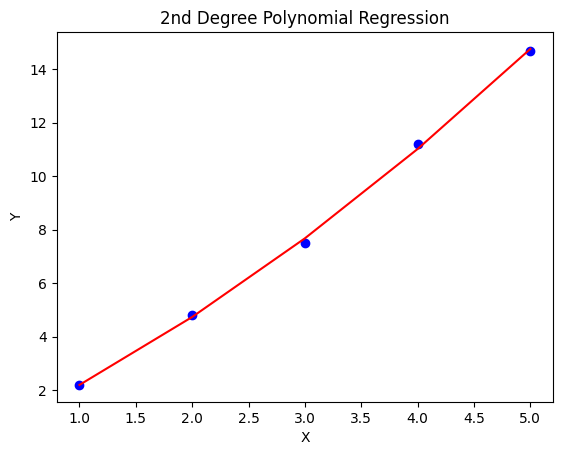

Coefficients: [0.   1.94 0.2 ]
Intercept: 0.06000000000000938


In [2]:
# 08)Question 8: Polynomial Regression

# Dataset:
# X = [1, 2, 3, 4, 5]
# Y = [2.2, 4.8, 7.5, 11.2, 14.7]
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, Y)

Y_pred = model.predict(X_poly)

plt.scatter(X, Y, color='blue')
plt.plot(X, Y_pred, color='red')
plt.title("2nd Degree Polynomial Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


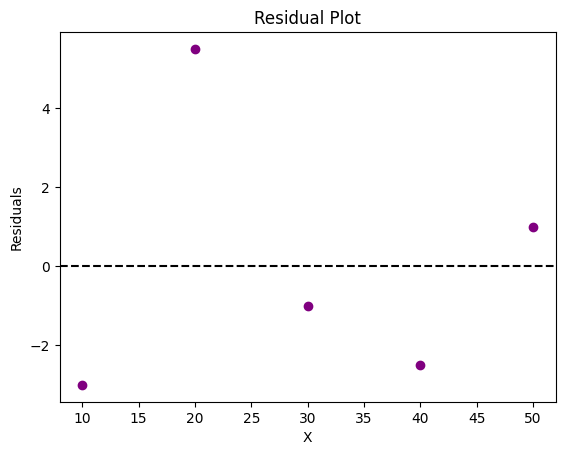

In [3]:
# Question 9: Residuals Plot & Heteroscedasticity

# Dataset:
# X = [10, 20, 30, 40, 50]
# Y = [15, 35, 40, 50, 65]

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([15, 35, 40, 50, 65])

model = LinearRegression()
model.fit(X, Y)
Y_pred = model.predict(X)

residuals = Y - Y_pred

plt.scatter(X, residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("X")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
# Interpretation:
# If residuals spread randomly → homoscedasticity (good).
# If spread increases/decreases with X → heteroscedasticity (problem).

In [ ]:
# Question 10: Handling Heteroscedasticity & Multicollinearity

# Answer:

# To address Heteroscedasticity:

# Apply log or square-root transformations on Y.

# Use Weighted Least Squares (WLS) or robust standard errors.

# Examine residual plots for confirmation.

# To address Multicollinearity:

# Compute VIF and remove variables with VIF > 10.

# Combine correlated variables (e.g., principal component analysis).

# Use Regularization (Ridge or Lasso Regression) to stabilize coefficients.